# Wildfire Detection

In [1]:
!pip install -q torch torchvision pillow -q

In [3]:
import os
import time
import zipfile
import shutil
from pathlib import Path
from google.colab import drive
from tqdm import tqdm

import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
from torchvision.transforms import Normalize, Resize, ToTensor, Compose, RandomHorizontalFlip, RandomRotation, ColorJitter, RandomResizedCrop
from torchvision import datasets
from transformers import ViTImageProcessor, ViTForImageClassification
from torchsummary import summary
from torch.optim.lr_scheduler import StepLR
from PIL import Image
from torchvision.io import decode_image
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import random

from sklearn.metrics import accuracy_score, recall_score, confusion_matrix, ConfusionMatrixDisplay, classification_report

In [4]:
# Device configuration (Use GPU if available, otherwise CPU)
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Running on device: {device}")

Running on device: cuda:0


## Loading the Data

Zip files are in the Google Drive. Each file has two folders - wildfire and nowildfire - that contain the images. This section extracts the zip files to the google colab file directory and creates dataset for training, validation, and testing.

In [5]:
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
# Configuration
DRIVE_ZIP_FOLDER = '/content/drive/MyDrive/STATS426FINAL files'
EXTRACT_BASE_PATH = '/content/data'  # Local extraction path
ZIP_FILES = ['train.zip', 'valid.zip', 'test.zip']  # List your zip files here

MODEL_SAVE_DIR = os.path.join(DRIVE_ZIP_FOLDER, 'models')

os.makedirs(EXTRACT_BASE_PATH, exist_ok=True)
os.makedirs(MODEL_SAVE_DIR, exist_ok=True)

print(f"Models will be saved to: {MODEL_SAVE_DIR}")

Models will be saved to: /content/drive/MyDrive/STATS426FINAL files/models


In [7]:
for zip_file in os.listdir(DRIVE_ZIP_FOLDER):
    if not zip_file.endswith('.zip'):
      continue
    zip_path = os.path.join(DRIVE_ZIP_FOLDER, zip_file)

    if not os.path.exists(zip_path):
        print(f"Warning: {zip_file} not found at {zip_path}")
        continue

    print(f"\nExtracting {zip_file}...")

    extract_subfolder = os.path.join(EXTRACT_BASE_PATH, Path(zip_file).stem)
    os.makedirs(extract_subfolder, exist_ok=True)

    # Extract zip file
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_subfolder)


Extracting valid.zip...

Extracting test.zip...

Extracting train.zip...


## Validate Data

In [ ]:
# running into this error when training:
# RuntimeError: Image is incomplete or truncated
# set up data validation to ensure all images can be decoded
for folder in os.listdir(EXTRACT_BASE_PATH):
    folder_path = os.path.join(EXTRACT_BASE_PATH, folder)
    if folder_path.lower().endswith('.zip'):
        continue
    print('Checking ', folder)
    for img_class in os.listdir(folder_path):
        class_path = os.path.join(folder_path, img_class)
        for img in os.listdir(class_path):
            # make sure that it's an image from the dataset
            if img.lower().endswith(('.jpg', 'jpeg')):
                img_path = os.path.join(class_path, img)
                try:
                    image = decode_image(img_path)  # func changes images into te
                    image = image.float() / 255.0
                except Exception as e:
                    print(f"Invalid image: {e}, image : {img_path}")

In [8]:
problem_imgs = ['/content/data/train/nowildfire/-114.152378,51.027198.jpg',
                '/content/data/test/wildfire/-73.15884,46.38819.jpg']
for i in problem_imgs:
  os.remove(i)

## Sanity Check

make sure expected number of files are present

In [ ]:
def count_files(folder_type):
  wf = train_count_wf = sum(1 for item in os.listdir(os.path.join(EXTRACT_BASE_PATH, folder_type, 'wildfire')))
  nowf = sum(1 for item in os.listdir(os.path.join(EXTRACT_BASE_PATH, folder_type, 'nowildfire')))
  print(f'Number of {folder_type} images: {wf} wildfire, {nowf} no wildfire')

In [ ]:
count_files('train')
count_files('valid')
count_files('test')

Number of train images: 15750 wildfire, 14499 no wildfire
Number of valid images: 3480 wildfire, 2820 no wildfire
Number of test images: 3479 wildfire, 2820 no wildfire


## Custom Dataset Function

In [9]:
# Custom dataset function for wildfire images from Google Drive zip
class WildfireDataset(Dataset):
    def __init__(self, data_dir, transform=None):
        """
        Args:
            data_dir: Path to folder containing 'wildfire' and 'nowildfire' subfolders
            transform: Optional transform to apply to images
        """
        self.data_dir = data_dir
        self.transform = transform
        self.image_paths = []
        self.labels = []

        # Class mapping
        class_map = {'wildfire': 1, 'nowildfire': 0}

        # Load image paths and labels
        # both wildfire and nowildfire image paths go into one array
        for class_name, label in class_map.items():
            class_path = os.path.join(data_dir, class_name)

            if os.path.exists(class_path):
                for img_name in os.listdir(class_path):
                    if img_name.lower().endswith(('.jpg', 'jpeg')):
                        self.image_paths.append(os.path.join(class_path, img_name))
                        self.labels.append(label)

    def __len__(self):
        return len(self.image_paths)

    # pulls actual image from class attribute image paths
    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        image = Image.open(img_path).convert('RGB') # just in case there are grayscale images
        label = self.labels[idx]

        if self.transform:
            image = self.transform(image)

        return image, label

## EDA

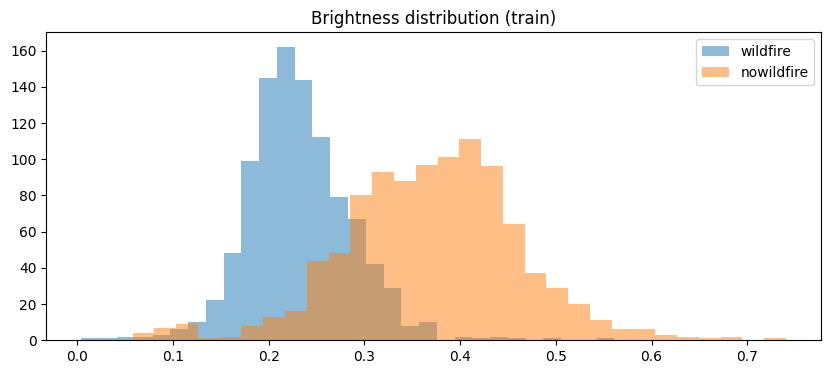

In [ ]:
def brightness_contrast(split_dir, cls, n=1000):
    cls_dir = os.path.join(split_dir, cls)
    files = [os.path.join(cls_dir, f) for f in os.listdir(cls_dir) if f.lower().endswith((".jpg",".jpeg",".png"))]
    files = random.sample(files, min(n, len(files)))

    b, c = [], []
    for p in files:
        img = Image.open(p).convert("RGB")
        arr = np.asarray(img).astype(np.float32) / 255.0
        gray = arr.mean(axis=2)
        b.append(gray.mean())
        c.append(gray.std())
    return np.array(b), np.array(c)

bw, cw = brightness_contrast("/content/data/train", "wildfire")
bn, cn = brightness_contrast("/content/data/train", "nowildfire")

plt.figure(figsize=(10,4))
plt.hist(bw, bins=30, alpha=0.5, label="wildfire")
plt.hist(bn, bins=30, alpha=0.5, label="nowildfire")
plt.title("Brightness distribution (train)")
plt.legend()
plt.show()

## CNN Baseline

In [ ]:
IMG_SIZE = 224
BATCH_SIZE = 64

imagenet_mean = (0.485, 0.456, 0.406)
imagenet_std  = (0.229, 0.224, 0.225)

train_tf = Compose([
    Resize((IMG_SIZE, IMG_SIZE)),
    RandomResizedCrop(IMG_SIZE, scale=(0.85, 1.0)),
    RandomHorizontalFlip(p=0.5),
    ColorJitter(brightness=0.15, contrast=0.15, saturation=0.10, hue=0.02),
    ToTensor(),
    Normalize(imagenet_mean, imagenet_std),
])

eval_tf = Compose([
    Resize((IMG_SIZE, IMG_SIZE)),
    ToTensor(),
    Normalize(imagenet_mean, imagenet_std),
])

In [ ]:
DATA_ROOT = "/content/data"
train_dir = os.path.join(DATA_ROOT, "train")
val_dir   = os.path.join(DATA_ROOT, "valid")
test_dir  = os.path.join(DATA_ROOT, "test")

train_ds = datasets.ImageFolder(train_dir, transform=train_tf)
val_ds   = datasets.ImageFolder(val_dir,   transform=eval_tf)
test_ds  = datasets.ImageFolder(test_dir,  transform=eval_tf)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print("class_to_idx:", train_ds.class_to_idx)
NUM_CLASSES = len(train_ds.classes)

# sanity check
x, y = next(iter(train_loader))
print(x.shape)  # should be [B, 3, 224, 224]

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
criterion = nn.CrossEntropyLoss()

def run_epoch(model, loader, optimizer=None):
    train_mode = optimizer is not None
    model.train() if train_mode else model.eval()

    total_loss, total_correct, total_n = 0.0, 0, 0

    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)

        if train_mode:
            optimizer.zero_grad()

        logits = model(xb)
        loss = criterion(logits, yb)

        if train_mode:
            loss.backward()
            optimizer.step()

        total_loss += loss.item() * xb.size(0)
        total_correct += (logits.argmax(1) == yb).sum().item()
        total_n += xb.size(0)

    return total_loss / total_n, total_correct / total_n


def train_model_timed(model, epochs=10, lr=1e-3, weight_decay=0.0):
    model = model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

    hist = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": [], "epoch_time_sec": []}

    best_val_acc = -1.0
    best_state = None

    for ep in range(1, epochs + 1):
        t0 = time.time()

        tr_loss, tr_acc = run_epoch(model, train_loader, optimizer)
        va_loss, va_acc = run_epoch(model, val_loader, optimizer=None)

        dt = time.time() - t0

        hist["train_loss"].append(tr_loss)
        hist["val_loss"].append(va_loss)
        hist["train_acc"].append(tr_acc)
        hist["val_acc"].append(va_acc)
        hist["epoch_time_sec"].append(dt)

        if va_acc > best_val_acc:
            best_val_acc = va_acc
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

        print(f"Epoch {ep:02d}/{epochs} | train loss {tr_loss:.4f} acc {tr_acc:.4f} | val loss {va_loss:.4f} acc {va_acc:.4f} | time {dt:.1f}s")

    model.load_state_dict(best_state)
    total_train_time = float(np.sum(hist["epoch_time_sec"]))
    return model, hist, total_train_time


def plot_loss_curves(hist, title):
    epochs = range(1, len(hist["train_loss"]) + 1)
    plt.figure(figsize=(8,5))
    plt.plot(epochs, hist["train_loss"], label="Train Loss")
    plt.plot(epochs, hist["val_loss"], "--", label="Val Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Cross-Entropy Loss")
    plt.title(title)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


def evaluate_with_time_and_recall(model, loader, class_to_idx, wildfire_name="wildfire"):
    model.eval()
    y_true, y_pred = [], []

    start = time.time()
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(device)
            logits = model(xb)
            preds = logits.argmax(1).cpu().numpy()
            y_pred.append(preds)
            y_true.append(yb.numpy())
    total_infer_time = time.time() - start

    y_true = np.concatenate(y_true)
    y_pred = np.concatenate(y_pred)

    cm = confusion_matrix(y_true, y_pred)
    names = list(class_to_idx.keys())
    print("Confusion Matrix:\n", cm)
    print("\nReport:\n", classification_report(y_true, y_pred, target_names=names, digits=4))

    recalls = cm.diagonal() / cm.sum(axis=1)
    recall_dict = {names[i]: float(recalls[i]) for i in range(len(names))}
    print("Recall by class:", recall_dict)

    wildfire_idx = class_to_idx.get(wildfire_name, None)
    if wildfire_idx is not None and wildfire_name in recall_dict:
        print("Wildfire recall:", recall_dict[wildfire_name])

    avg_ms = (total_infer_time / len(y_true)) * 1000.0
    print(f"Inference time (total): {total_infer_time:.2f}s | per image: {avg_ms:.3f} ms")
    return recall_dict, total_infer_time


def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

In [ ]:
class BaselineCNN(nn.Module):
    def __init__(self, num_classes=2):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2,2),

            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2,2),

            nn.Conv2d(64, 128, 3, padding=1), nn.ReLU(),
        )
        self.gap = nn.AdaptiveAvgPool2d((1,1))
        self.classifier = nn.Linear(128, num_classes)

    def forward(self, x):
        x = self.features(x)
        x = self.gap(x).view(x.size(0), -1)
        return self.classifier(x)

In [ ]:
class EnhancedCNN(nn.Module):
    def __init__(self, num_classes=2, dropout=0.4):
        super().__init__()
        self.block1 = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2,2),
        )
        self.block2 = nn.Sequential(
            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2,2),
        )
        self.block3 = nn.Sequential(
            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
        )
        self.gap = nn.AdaptiveAvgPool2d((1,1))
        self.drop = nn.Dropout(dropout)
        self.fc = nn.Linear(128, num_classes)

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.gap(x).view(x.size(0), -1)
        x = self.drop(x)
        return self.fc(x)

In [ ]:
# ---- Train + evaluate BaselineCNN ----
EPOCHS = 10

baseline_cnn = BaselineCNN(num_classes=NUM_CLASSES)
print("BaselineCNN params:", count_params(baseline_cnn))

baseline_cnn, hist_base, train_time_base = train_model_timed(
    baseline_cnn, epochs=EPOCHS, lr=1e-3, weight_decay=0.0
)
print(f"BaselineCNN total training time: {train_time_base:.1f}s | avg per epoch: {train_time_base/EPOCHS:.1f}s")

plot_loss_curves(hist_base, "BaselineCNN: Train vs Val Loss")

print("\nBaselineCNN test evaluation:")
recall_base, infer_time_base = evaluate_with_time_and_recall(
    baseline_cnn, test_loader, train_ds.class_to_idx
)

In [ ]:
# ---- Train + evaluate EnhancedCNN ----
EPOCHS = 10

enhanced_cnn = EnhancedCNN(num_classes=NUM_CLASSES, dropout=0.4)
print("EnhancedCNN params:", count_params(enhanced_cnn))

enhanced_cnn, hist_enh, train_time_enh = train_model_timed(
    enhanced_cnn, epochs=EPOCHS, lr=1e-3, weight_decay=1e-4
)
print(f"EnhancedCNN total training time: {train_time_enh:.1f}s | avg per epoch: {train_time_enh/EPOCHS:.1f}s")

plot_loss_curves(hist_enh, "EnhancedCNN: Train vs Val Loss")

print("\nEnhancedCNN test evaluation:")
recall_enh, infer_time_enh = evaluate_with_time_and_recall(
    enhanced_cnn, test_loader, train_ds.class_to_idx
)

# ResNet18

In [ ]:
import os
import zipfile
import shutil
from pathlib import Path
from google.colab import drive

import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import numpy as np
import pandas as pd
from PIL import Image, ImageFile

In [ ]:
# now create dataloaders to iterate over images
train_dataloader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_dataloader = DataLoader(val_dataset, batch_size=64, shuffle=True)
test_dataloader = DataLoader(test_dataset, batch_size=64, shuffle=True)

In [ ]:
import torchvision.models as models
import torch.nn as nn
import torch.optim as optim

# 加载预训练的ResNet18模型
model = models.resnet18(weights='IMAGENET1K_V1')  # 使用新的API

# 修改最后一层以适应二分类任务（wildfire/nowildfire）
num_classes = 2
num_features = model.fc.in_features
model.fc = nn.Linear(num_features, num_classes)

print(f"模型结构已修改：最后一层输出维度 = {num_classes}")

# 检查是否有GPU可用
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Facility Equipment {device}")
model = model.to(device)

模型结构已修改：最后一层输出维度 = 2
Facility Equipment cuda


In [ ]:
# 添加数据预处理transform（如果数据集还没有transform）
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                        std=[0.229, 0.224, 0.225])  # ImageNet标准化
])

val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                        std=[0.229, 0.224, 0.225])
])

# 重新创建带transform的数据集
train_dataset = WildfireDataset(os.path.join(EXTRACT_BASE_PATH, 'train'), transform=train_transform)
val_dataset = WildfireDataset(os.path.join(EXTRACT_BASE_PATH, 'valid'), transform=val_test_transform)
test_dataset = WildfireDataset(os.path.join(EXTRACT_BASE_PATH, 'test'), transform=val_test_transform)

# 重新创建DataLoader（验证集和测试集不打乱）
train_dataloader = DataLoader(train_dataset, batch_size=64, shuffle=True, num_workers=2)
val_dataloader = DataLoader(val_dataset, batch_size=64, shuffle=False, num_workers=2)
test_dataloader = DataLoader(test_dataset, batch_size=64, shuffle=False, num_workers=2)

print("数据加载器已创建")

数据加载器已创建


In [ ]:
# 定义损失函数和优化器
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=7, gamma=0.1)  # 每7个epoch降低学习率


In [ ]:
# 训练函数
def train_epoch(model, dataloader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in dataloader:
        images = images.to(device)
        labels = labels.to(device)

        # 前向传播
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)

        # 反向传播
        loss.backward()
        optimizer.step()

        # 统计
        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / len(dataloader)
    epoch_acc = 100 * correct / total
    return epoch_loss, epoch_acc


# 验证函数
def validate_epoch(model, dataloader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / len(dataloader)
    epoch_acc = 100 * correct / total
    return epoch_loss, epoch_acc

print("训练和验证函数已定义")

训练和验证函数已定义


In [ ]:
train_losses

[0.14399907352839916, 0.09548984581395889]

In [ ]:
# 训练模型
num_epochs = 10
best_val_acc = 0.0
train_losses = []
train_accs = []
val_losses = []
val_accs = []

print("开始训练...")
print("-" * 60)

for epoch in range(num_epochs):
    # 训练
    train_loss, train_acc = train_epoch(model, train_dataloader, criterion, optimizer, device)
    train_losses.append(train_loss)
    train_accs.append(train_acc)

    # 验证
    val_loss, val_acc = validate_epoch(model, val_dataloader, criterion, device)
    val_losses.append(val_loss)
    val_accs.append(val_acc)

    # 更新学习率
    scheduler.step()

    # 打印结果
    print(f'Epoch [{epoch+1}/{num_epochs}]')
    print(f'Train - Loss: {train_loss:.4f}, Acc: {train_acc:.2f}%')
    print(f'Validation - Loss: {val_loss:.4f}, Acc: {val_acc:.2f}%')
    print(f'学习率: {scheduler.get_last_lr()[0]:.6f}')

    # 保存最佳模型
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), 'best_resnet18_model.pth')
        print(f'✓ Save the best model (Validation Accuracy: {val_acc:.2f}%)')

    print("-" * 60)

print(f'\nTrain Finished! Best Val Accuracy: {best_val_acc:.2f}%')

开始训练...
------------------------------------------------------------
Epoch [1/10]
训练 - Loss: 0.1440, Acc: 94.44%
验证 - Loss: 0.2123, Acc: 91.90%
学习率: 0.001000
✓ 保存最佳模型 (验证准确率: 91.90%)
------------------------------------------------------------
Epoch [2/10]
训练 - Loss: 0.0955, Acc: 96.56%
验证 - Loss: 0.1270, Acc: 95.11%
学习率: 0.001000
✓ 保存最佳模型 (验证准确率: 95.11%)
------------------------------------------------------------


KeyboardInterrupt: 

In [ ]:
import pandas as pd


num_epochs = 3
best_val_acc = 0.0


history_df = pd.DataFrame(columns=['Epoch', 'Train_Loss', 'Train_Acc', 'Val_Loss', 'Val_Acc', 'Learning_Rate'])

print("开始训练...")
print("-" * 60)

for epoch in range(num_epochs):

    train_loss, train_acc = train_epoch(model, train_dataloader, criterion, optimizer, device)


    val_loss, val_acc = validate_epoch(model, val_dataloader, criterion, device)


    current_lr = scheduler.get_last_lr()[0]

    # 添加到 DataFrame
    new_row = pd.DataFrame({
        'Epoch': [epoch + 1],
        'Train_Loss': [train_loss],
        'Train_Acc': [train_acc],
        'Val_Loss': [val_loss],
        'Val_Acc': [val_acc],
        'Learning_Rate': [current_lr]
    })

    history_df = pd.concat([history_df, new_row], ignore_index=True)

    # 更新学习率
    scheduler.step()

    # 打印结果
    print(f'Epoch [{epoch+1}/{num_epochs}]')
    print(f'Train - Loss: {train_loss:.4f}, Acc: {train_acc:.2f}%')
    print(f'Validation - Loss: {val_loss:.4f}, Acc: {val_acc:.2f}%')
    print(f'学习率: {current_lr:.6f}')

    # 保存最佳模型
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), 'best_resnet18_model.pth')
        print(f'✓ Save the best model (Validation Accuracy: {val_acc:.2f}%)')

    # 保存到CSV
    history_df.to_csv('training_history.csv', index=False)

    print("-" * 60)

print(f'\nTrain Finished! Best Val Accuracy: {best_val_acc:.2f}%')
print('训练历史已保存到: training_history.csv')

# 显示训练历史
print("\n训练历史摘要:")
print(history_df)

开始训练...
------------------------------------------------------------
Epoch [1/3]
Train - Loss: 0.0621, Acc: 97.74%
Validation - Loss: 0.0705, Acc: 97.71%
学习率: 0.001000
✓ Save the best model (Validation Accuracy: 97.71%)
------------------------------------------------------------


/tmp/ipython-input-3143114771.py:32: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  history_df = pd.concat([history_df, new_row], ignore_index=True)


Epoch [2/3]
Train - Loss: 0.0492, Acc: 98.26%
Validation - Loss: 0.0454, Acc: 98.62%
学习率: 0.001000
✓ Save the best model (Validation Accuracy: 98.62%)
------------------------------------------------------------
Epoch [3/3]
Train - Loss: 0.0488, Acc: 98.25%
Validation - Loss: 0.0595, Acc: 98.06%
学习率: 0.001000
------------------------------------------------------------

Train Finished! Best Val Accuracy: 98.62%
训练历史已保存到: training_history.csv

训练历史摘要:
  Epoch  Train_Loss  Train_Acc  Val_Loss    Val_Acc  Learning_Rate
0     1    0.062113  97.742149  0.070530  97.714286          0.001
1     2    0.049183  98.261157  0.045416  98.619048          0.001
2     3    0.048842  98.254545  0.059510  98.063492          0.001


In [ ]:
# 在测试集上评估模型
print("在测试集上评估模型...")
model.load_state_dict(torch.load('best_resnet18_model.pth'))
test_loss, test_acc = validate_epoch(model, test_dataloader, criterion, device)
print(f"测试集 - Loss: {test_loss:.4f}, Acc: {test_acc:.2f}%")

在测试集上评估模型...
测试集 - Loss: 0.0348, Acc: 98.81%


# Vision Transformer

For ablation studies - come up with a baseline, then experiment with: learning rate, freezing strategy, learning step scheduler, weight decay...



https://docs.pytorch.org/vision/main/models/vision_transformer.html

base version - ~86M parameters, moderate accuracy and speed

_32 — splits into 32×32 pixel patches → fewer patches, coarser detail, faster and cheaper - probably don't need so much detail?

In [11]:
# VIT CONFIGURATION PARAMETERS
LR = 0.001
EPOCHS = 10
BATCH_SIZE = 64
WEIGHT_DECAY = 0.01
WARMUP_EPOCHS = 3
SCHEDULER = None
VERSION = 'v1'

PATIENCE = 3
# current baseline: freeze early 8 layers out of 12, fine-tune later layers

# set seed
seed = 2024
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
random.seed(seed)
np.random.seed(seed)

# things to try: freezing strategy, using step scheduler (step or cosine), higher weight decay, lower learning rate?
# removing data augmentation, including warmup epochs

In [12]:
model_name = "google/vit-base-patch16-224"

processor = ViTImageProcessor.from_pretrained(model_name)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/160 [00:00<?, ?B/s]

In [13]:
mu, sigma = processor.image_mean, processor.image_std #get default mu,sigma
size = processor.size

# build transform pipeline: resize 350x350 to 224x224 ->
# data augmentation ->
# convert to Pytorch tensor ->
# normalize
train_transform = Compose([
    Resize(size['height']),
    RandomHorizontalFlip(p=0.5),
    RandomRotation(10),
    ColorJitter(brightness=0.2, contrast=0.2),
    ToTensor(),
    Normalize(mean=mu, std=sigma) #normalize image pixels range to [-1,1]
])

val_test_transform = Compose([
    Resize(size['height']),
    ToTensor(),
    Normalize(mean=mu, std=sigma)
])

# apply transforms to PIL Image and store it to 'pixels' key
def transf(arg):
    arg['pixels'] = [train_transform(image.convert('RGB')) for image in arg['img']]
    return arg

In [14]:
train_dataset = WildfireDataset(os.path.join(EXTRACT_BASE_PATH, 'train'), transform=train_transform)
val_dataset = WildfireDataset(os.path.join(EXTRACT_BASE_PATH, 'valid'), transform=val_test_transform)
test_dataset = WildfireDataset(os.path.join(EXTRACT_BASE_PATH, 'test'), transform=val_test_transform)

train_dataloader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_dataloader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_dataloader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

In [15]:
vit = ViTForImageClassification.from_pretrained(model_name, num_labels=2,
                                                ignore_mismatched_sizes=True,
                                                id2label={0: 'nowildfire', 1: 'wildfire'},
                                                label2id={'nowildfire': 0, 'wildfire': 1})
# Freeze the first 8 encoder layers
for i, layer in enumerate(vit.vit.encoder.layer):
    if i < 8: # Freeze first 8 of 12 layers
        for param in layer.parameters():
            param.requires_grad = False

# Option B: Freeze entire backbone, train head only ?????
# for param in vit.parameters():
#     param.requires_grad = False

vit.to(device)

print(vit.classifier)

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

ViTForImageClassification LOAD REPORT from: google/vit-base-patch16-224
Key               | Status   |                                                                                        
------------------+----------+----------------------------------------------------------------------------------------
classifier.weight | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([1000, 768]) vs model:torch.Size([2, 768])
classifier.bias   | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([1000]) vs model:torch.Size([2])          

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.


Linear(in_features=768, out_features=2, bias=True)


In [19]:
# Calculate total parameters
total_params = sum(p.numel() for p in vit.parameters())

# Calculate trainable parameters
trainable_params = sum(p.numel() for p in vit.parameters() if p.requires_grad)

print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

Total parameters: 85,800,194
Trainable parameters: 29,097,218


In [ ]:
mod_file = 'vit-mod-' + VERSION
df_file = 'vit_training_history-' + VERSION + '.csv'
SAVE_PATH = os.path.join(MODEL_SAVE_DIR, mod_file) # Update SAVE_PATH to Google Drive
SAVE_PATH_HIST = os.path.join(MODEL_SAVE_DIR, df_file)

# things to experiment with: weight decay, learning rate, different optimizers
optimizer = torch.optim.Adam(
    vit.parameters(),
    lr=LR,
    weight_decay=WEIGHT_DECAY
)
criterion  = nn.CrossEntropyLoss()

In [ ]:
def run_epoch(model, loader, training=True):
    model.train() if training else model.eval()
    total_loss, correct, total = 0.0, 0, 0

    ctx = torch.enable_grad() if training else torch.no_grad()
    with ctx:
        for images, labels in tqdm(loader, desc="Train" if training else "Val", leave=False):
            images, labels = images.to(device), labels.to(device)

            outputs = model(pixel_values=images)   # HuggingFace ViT expects 'pixel_values'
            loss    = criterion(outputs.logits, labels)

            if training:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

            total_loss += loss.item() * images.size(0)
            preds       = outputs.logits.argmax(dim=1)
            correct    += (preds == labels).sum().item()
            total      += images.size(0)


    return total_loss / total, correct / total

In [ ]:
best_val_acc = 0.0
history = {'train_loss': [], 'train_acc': [], 'val_acc': [], 'val_loss': [],
           'epoch_times': []}
epochs_no_improve = 0
best_val_loss = float('inf')
best_model_state = None

for epoch in range(1, EPOCHS + 1):
    epoch_start = time.time()
    train_loss, train_acc = run_epoch(vit, train_dataloader, training=True)
    epoch_time = time.time() - epoch_start
    history['epoch_times'].append(epoch_time)

    val_loss,   val_acc   = run_epoch(vit, val_dataloader,   training=False)

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)

    print(f"Epoch {epoch:02d}/{EPOCHS} | "
          f"Train Loss: {train_loss:.4f}  Acc: {train_acc:.4f} | "
          f"Val Loss:   {val_loss:.4f}  Acc: {val_acc:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_val_acc = val_acc
        best_model_state = vit.state_dict().copy()
        epochs_no_improve = 0
        torch.save(vit.state_dict(), SAVE_PATH)
        print(f"  ✓ Saved new best model (val_loss={val_loss:.4f})")
    # no improvement - don't want to record model current state
    else:
        epochs_no_improve += 1

    if epochs_no_improve >= PATIENCE:
      print(f"\nEarly stopping at epoch {epoch+1} (no improvement for {PATIENCE} epochs)")
      break

    if SCHEDULER is not None:
        SCHEDULER.step()

print(f"\nTraining complete. Best val accuracy: {best_val_acc:.4f}, best val loss: {best_val_loss:.4f}")

history_df = pd.DataFrame(history)
history_df.to_csv(SAVE_PATH_HIST, index=False)
print(f"Training history saved to: {SAVE_PATH_HIST}")

RuntimeError: element 0 of tensors does not require grad and does not have a grad_fn

In [ ]:
# reload best model after saving
vit.load_state_dict(torch.load(SAVE_PATH, map_location=device))
history_df = pd.read_csv(SAVE_PATH_HIST)

In [ ]:
def evaluate_model_on_dataloader(model, dataloader, criterion, device):
    model.eval()
    total_loss = 0.0
    all_labels = []
    all_preds = []

    with torch.no_grad():
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(pixel_values=images)
            loss = criterion(outputs.logits, labels)
            total_loss += loss.item() * images.size(0)

            preds = outputs.logits.argmax(dim=1)
            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())

    avg_loss = total_loss / len(dataloader.dataset)
    accuracy = accuracy_score(all_labels, all_preds)
    recall = recall_score(all_labels, all_preds, average='binary') # 'binary' for 2 classes
    conf_matrix = confusion_matrix(all_labels, all_preds)

    return avg_loss, accuracy, recall, conf_matrix, all_labels, all_preds

In [ ]:
def plot_train_val_curve(train_loss, val_loss):
  fig, ax = plt.subplots(figsize=(10, 6))

  ax.plot(train_loss, label='Train Loss', linewidth=2)
  ax.plot(val_loss, label='Val Loss', linewidth=2, linestyle='--')
  ax.set_xlabel('Epochs')
  ax.set_ylabel('Cross Entropy Loss')
  ax.set_title('Training and Validation Loss')
  ax.legend()
  ax.grid(True, alpha=0.3)

  plt.tight_layout()
  plt.show()

In [ ]:
history_df

,train_loss,train_acc,val_acc,val_loss,epoch_times
0,0.134475,0.949717,0.971111,0.083162,161.316957
1,0.096087,0.964759,0.976825,0.069116,161.005439
2,0.087712,0.967272,0.947143,0.144065,160.974211
3,0.096832,0.963800,0.968730,0.084163,161.059148
4,0.104302,0.961024,0.964286,0.101334,161.095105


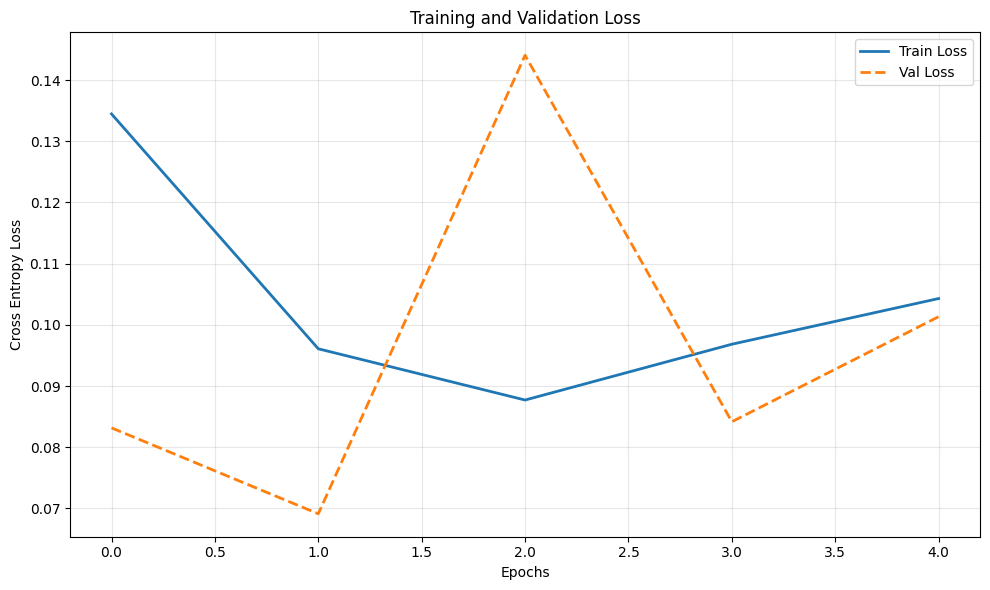

In [ ]:
plot_train_val_curve(history_df['train_loss'], history_df['val_loss'])

Evaluating ViT model on the test set...

Test Loss: 0.0551
Test Accuracy: 0.9830
Test Recall: 0.9914
Confusion Matrix:
[[2743   77]
 [  30 3449]]

Example of misclassified 'no wildfire' as 'wildfire':
  Image Path: /content/data/test/nowildfire/-75.773823,45.427802.jpg
  True Label: 0 (no wildfire)
  Predicted Label: 1 (wildfire)


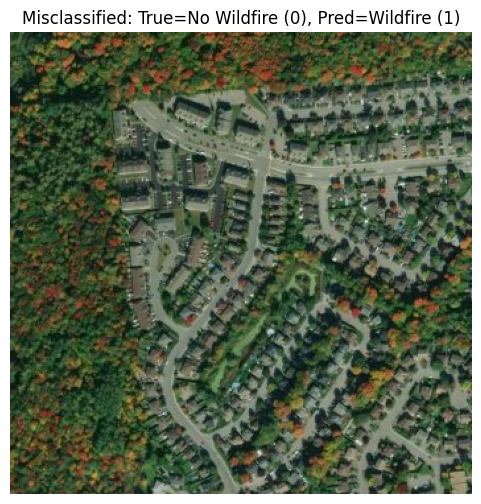

In [ ]:
print("Evaluating ViT model on the test set...")
test_loss, test_accuracy, test_recall, test_conf_matrix, all_true_labels, all_predicted_labels = evaluate_model_on_dataloader(
    vit, test_dataloader, criterion, device
)

print(f"\nTest Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test Recall: {test_recall:.4f}")
print("Confusion Matrix:")
print(test_conf_matrix)

misclassified_found = False
for i in range(len(all_true_labels)):
    true_label = all_true_labels[i]
    predicted_label = all_predicted_labels[i]

    # Check for misclassified: true=0 (no wildfire), predicted=1 (wildfire)
    if true_label == 0 and predicted_label == 1:
        misclassified_found = True
        image_path = test_dataset.image_paths[i]
        print(f"\nExample of misclassified 'no wildfire' as 'wildfire':")
        print(f"  Image Path: {image_path}")
        print(f"  True Label: {true_label} (no wildfire)")
        print(f"  Predicted Label: {predicted_label} (wildfire)")
        try:
            img = Image.open(image_path).convert('RGB')
            plt.figure(figsize=(6,6))
            plt.imshow(img)
            plt.title(f"Misclassified: True=No Wildfire ({true_label}), Pred=Wildfire ({predicted_label})")
            plt.axis('off')
            plt.show()
        except Exception as e:
            print(f"Could not display image {image_path}: {e}")
        break # Only display the first one found

if not misclassified_found:
    print("\nNo 'no wildfire' images were misclassified as 'wildfire' in the test set.")

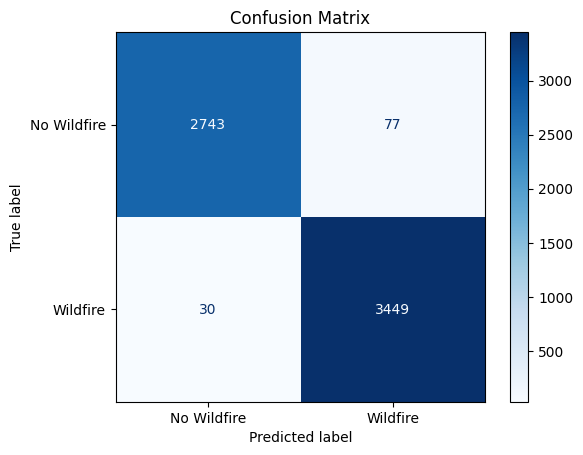

In [ ]:
disp = ConfusionMatrixDisplay(confusion_matrix=test_conf_matrix, display_labels=['No Wildfire', 'Wildfire'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix')
plt.show()

In [ ]:
print(f'Average epoch time: {history_df['epoch_times'].mean()}')

Average epoch time: 160.91095893383027


In [ ]:
# summary of experiments so far
# index 0 can be baseline for ablation studies? not sure if we should include early stopping
experiments = pd.DataFrame(columns=['learning_rate', 'epochs', 'early stopping', 'batch_size', 'weight_decay', 'warmup_epochs', 'scheduler', 'freezing strat', 'data aug', 'test loss', 'test recall', 'test acc', 'epoch avg time (s)', 'gpu'])
experiments.loc[len(experiments)] = [0.001, 6, 'yes', 64, 0.01, 3, None, 'freeze early 8 layers', 'yes', 0.1707, 0.9503, 0.9389, 160.95, 'A100']
experiments.loc[len(experiments)] = [0.0001, 6, 'yes', 64, 0.01, 3, None, 'freeze early 8 layers', 'yes', 0.0551, 0.9914, 0.9830, 161.09, 'A100']
experiments.loc[len(experiments)] = [0.001, 10, 'yes', 64, 0.1, 3, None, 'freeze early 8 layers', 'yes', 0.2057, 0.9437, 0.9238, 160.91, 'A100']

experiments.sort_values(by='test recall', ascending=False)

,learning_rate,epochs,early stopping,batch_size,weight_decay,warmup_epochs,scheduler,freezing strat,data aug,test loss,test recall,test acc,epoch avg time (s),gpu
1,0.0001,6,yes,64,0.01,3,None,freeze early 8 layers,yes,0.0551,0.9914,0.9830,161.09,A100
0,0.0010,6,yes,64,0.01,3,None,freeze early 8 layers,yes,0.1707,0.9503,0.9389,160.95,A100
2,0.0010,10,yes,64,0.10,3,None,freeze early 8 layers,yes,0.2057,0.9437,0.9238,160.91,A100


## Plotting ViT Attention Maps

In [ ]:
SAVE_PATH

'/content/drive/MyDrive/STATS426FINAL files/models/vit-mod-v1'

In [ ]:
# Load a pre-trained ViT model and feature extractor
processor = ViTImageProcessor.from_pretrained(model_name, do_rescale=False)
vit = ViTForImageClassification.from_pretrained(model_name, num_labels=2,
                                                ignore_mismatched_sizes=True,
                                                id2label={0: 'nowildfire', 1: 'wildfire'},
                                                label2id={'nowildfire': 0, 'wildfire': 1},
                                                attn_implementation="eager")

vit.load_state_dict(torch.load(SAVE_PATH, map_location=device))

# Run an image through the pipline
tester_img = Image.open("/content/data/test/wildfire/-62.77115,51.54497.jpg").convert("RGB")
inputs = processor(images=tester_img, return_tensors="pt")
outputs = vit(**inputs, output_attentions=True)

# Getting the attentions
attentions = outputs.attentions

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

ViTForImageClassification LOAD REPORT from: google/vit-base-patch16-224
Key               | Status   |                                                                                        
------------------+----------+----------------------------------------------------------------------------------------
classifier.bias   | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([1000]) vs model:torch.Size([2])          
classifier.weight | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([1000, 768]) vs model:torch.Size([2, 768])

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.


In [ ]:
patch_grid = 14
num_of_patches = 196
num_tokens  = 197

In [ ]:
# a tuple of 12 tensors
print(torch.tensor(attentions[0]).shape) # batch size by number of heads by query tokens by key tokens

torch.Size([1, 12, 197, 197])


/tmp/ipykernel_4552/3392983705.py:1: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  print(torch.tensor(attentions[0]).shape) # 12 x 1 x 12 x 197


In [ ]:
def attention_rollout(attentions):
    # Initialize rollout with identity matrix
    rollout = torch.eye(attentions[0].size(-1)).to(attentions[0].device)

    # Multiply attention maps layer by layer
    for attention in attentions:
        attention_heads_fused = attention.mean(dim=1) # Average attention across heads
        attention_heads_fused += torch.eye(attention_heads_fused.size(-1)).to(attention_heads_fused.device) # A + I
        attention_heads_fused /= attention_heads_fused.sum(dim=-1, keepdim=True) # Normalizing A
        rollout = torch.matmul(rollout, attention_heads_fused) # Multiplication

    return rollout

In [ ]:
rollout = attention_rollout(attentions)

cls_attention = rollout[0, 1:, 0]  # Get attention values from [CLS] token to all patches
cls_attention = 1 - cls_attention.reshape(int(np.sqrt(num_of_patches)), int(np.sqrt(num_of_patches)))

In [ ]:
from PIL import Image, ImageFilter

# Normalize the attention map for better visualization
cls_attention = (cls_attention - cls_attention.min()) / (cls_attention.max() - cls_attention.min())
cls_attention = cls_attention.detach().numpy()

# Resize and blur the attention map
cls_attention_resized = Image.fromarray((cls_attention * 255).astype(np.uint8)).resize((350, 350), resample=Image.BICUBIC)
cls_attention_resized = cls_attention_resized.filter(ImageFilter.GaussianBlur(radius=2))

In [ ]:
# Convert the attention map to RGBA
cls_attention_colored = np.array(cls_attention_resized.convert("L"))
cls_attention_colored = np.stack([cls_attention_colored]*3 + [cls_attention_colored], axis=-1)

# Adjust the alpha channel to control brightness
cls_attention_colored_img = Image.fromarray(cls_attention_colored, mode="RGBA")
cls_attention_colored_img.putalpha(100)  # Adjust alpha for blending (lower val

/tmp/ipykernel_4552/571059957.py:6: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  cls_attention_colored_img = Image.fromarray(cls_attention_colored, mode="RGBA")


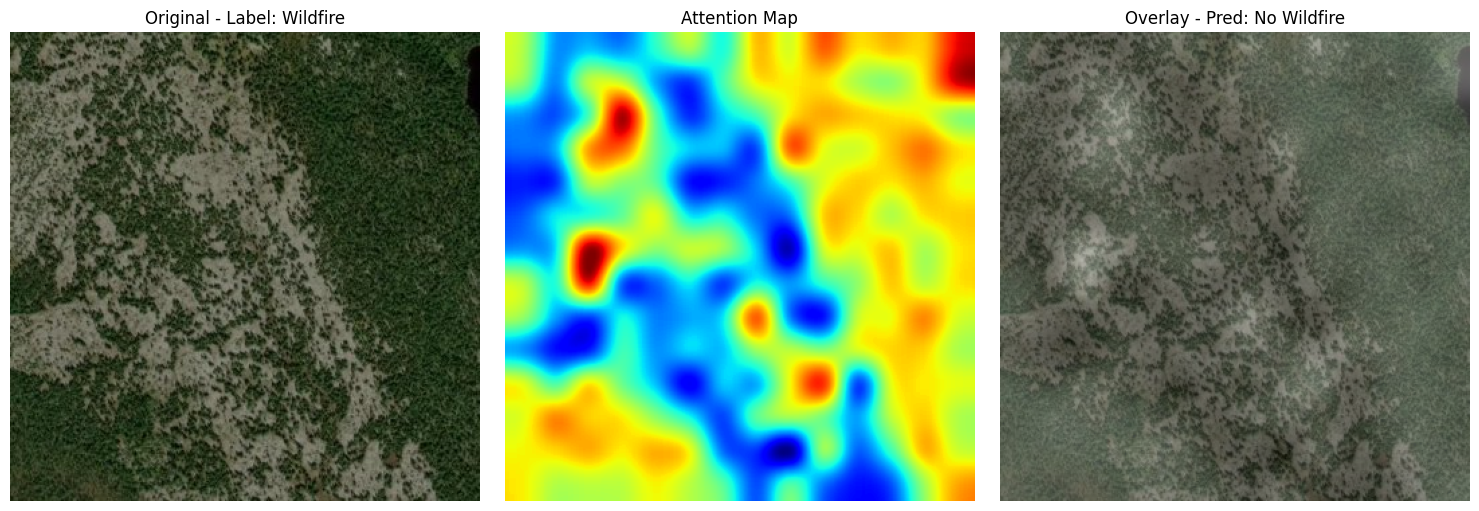

In [ ]:
import matplotlib.pyplot as plt

# Prepare original image for display
original_image = tester_img.resize((350, 350))

# Composite and display
original_rgba = original_image.convert("RGBA")
combined = Image.alpha_composite(original_rgba, cls_attention_colored_img)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(original_image)
axes[0].set_title(f"Original - Label: Wildfire")
axes[1].imshow(cls_attention_resized, cmap='jet')
axes[1].set_title("Attention Map")
axes[2].imshow(combined)
axes[2].set_title(f"Overlay - Pred: {'Wildfire' if outputs.logits.argmax() == 1 else 'No Wildfire'}")
for ax in axes: ax.axis('off')
plt.tight_layout()
plt.show()

# tutorial: https://medium.com/@nivonl/exploring-visual-attention-in-transformer-models-ab538c06083a

In [ ]:
# create requirements.txt
!pip freeze > requirements.txt